Part I: Randomized Sales Data Generation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize Random Seed
roll_number = 8025320102
np.random.seed(roll_number % 1000)

# 2. Generate Sales Data (12 months, 4 categories)
sales_data = np.random.randint(1000, 5000, size=(12, 4))

# 3. Convert to DataFrame
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

columns = ["Electronics", "Clothing", "Home & Kitchen", "Sports"]

df = pd.DataFrame(sales_data, columns=columns, index=months)
df

,Electronics,Clothing,Home & Kitchen,Sports
Jan,3304,1755,3638,3290
Feb,3674,1879,3882,1969
Mar,4016,3093,3376,4145
Apr,1079,3951,3820,2783
May,4696,2702,4538,1439
Jun,2411,4040,1128,2232
Jul,4655,4481,4100,3971
Aug,2406,1071,1158,4694
Sep,3820,2455,1217,1995
Oct,3946,1043,3687,4366


Part II: Data Manipulation and Analysis

Display Data

In [2]:
# First 5 rows
df.head()

# Summary statistics
df.describe()

,Electronics,Clothing,Home & Kitchen,Sports
count,12.000000,12.000000,12.000000,12.000000
mean,3082.083333,2933.916667,3086.833333,3158.500000
std,1272.102230,1310.008221,1212.620516,1187.893514
min,1079.000000,1043.000000,1128.000000,1439.000000
25%,2248.250000,1848.000000,2668.250000,2172.750000
50%,3489.000000,2897.500000,3507.000000,3036.500000
75%,3963.500000,4019.750000,3835.500000,4200.250000
max,4696.000000,4724.000000,4538.000000,4751.000000


Total Sales

In [3]:
# Total per category
category_total = df.sum()
print("Total Sales per Category:\n", category_total)

# Total per month
df["Total Sales"] = df.sum(axis=1)
df

Total Sales per Category:
 Electronics       36985
Clothing          35207
Home & Kitchen    37042
Sports            37902
dtype: int64


,Electronics,Clothing,Home & Kitchen,Sports,Total Sales
Jan,3304,1755,3638,3290,11987
Feb,3674,1879,3882,1969,11404
Mar,4016,3093,3376,4145,14630
Apr,1079,3951,3820,2783,11633
May,4696,2702,4538,1439,13375
Jun,2411,4040,1128,2232,9811
Jul,4655,4481,4100,3971,17207
Aug,2406,1071,1158,4694,9329
Sep,3820,2455,1217,1995,9487
Oct,3946,1043,3687,4366,13042


Growth Calculation

In [4]:
# Growth per category
growth = df[columns].pct_change()
print("Growth per category:\n", growth)

# Growth rate for total sales
df["Growth Rate"] = df["Total Sales"].pct_change() * 100
df

Growth per category:
      Electronics  Clothing  Home & Kitchen    Sports
Jan          NaN       NaN             NaN       NaN
Feb     0.111985  0.070655        0.067070 -0.401520
Mar     0.093087  0.646088       -0.130345  1.105130
Apr    -0.731325  0.277401        0.131517 -0.328589
May     3.352178 -0.316123        0.187958 -0.482932
Jun    -0.486584  0.495189       -0.751432  0.551077
Jul     0.930734  0.109158        2.634752  0.779122
Aug    -0.483136 -0.760991       -0.717561  0.182070
Sep     0.587697  1.292250        0.050950 -0.574989
Oct     0.032984 -0.575153        2.029581  1.188471
Nov    -0.695134  2.847555       -0.145104  0.088181
Dec     0.475478  0.177174        0.061548 -0.522837


,Electronics,Clothing,Home & Kitchen,Sports,Total Sales,Growth Rate
Jan,3304,1755,3638,3290,11987,NaN
Feb,3674,1879,3882,1969,11404,-4.863602
Mar,4016,3093,3376,4145,14630,28.288320
Apr,1079,3951,3820,2783,11633,-20.485304
May,4696,2702,4538,1439,13375,14.974641
Jun,2411,4040,1128,2232,9811,-26.646729
Jul,4655,4481,4100,3971,17207,75.384772
Aug,2406,1071,1158,4694,9329,-45.783693
Sep,3820,2455,1217,1995,9487,1.693643
Oct,3946,1043,3687,4366,13042,37.472331


Discount Logic

In [5]:
# Apply discount based on roll number
if roll_number % 2 == 0:
    df["Electronics"] = df["Electronics"] * 0.9
    print("10% discount applied on Electronics")
else:
    df["Clothing"] = df["Clothing"] * 0.85
    print("15% discount applied on Clothing")

df

10% discount applied on Electronics


,Electronics,Clothing,Home & Kitchen,Sports,Total Sales,Growth Rate
Jan,2973.6,1755,3638,3290,11987,NaN
Feb,3306.6,1879,3882,1969,11404,-4.863602
Mar,3614.4,3093,3376,4145,14630,28.288320
Apr,971.1,3951,3820,2783,11633,-20.485304
May,4226.4,2702,4538,1439,13375,14.974641
Jun,2169.9,4040,1128,2232,9811,-26.646729
Jul,4189.5,4481,4100,3971,17207,75.384772
Aug,2165.4,1071,1158,4694,9329,-45.783693
Sep,3438.0,2455,1217,1995,9487,1.693643
Oct,3551.4,1043,3687,4366,13042,37.472331


Part III: Visualizations

Line Plot

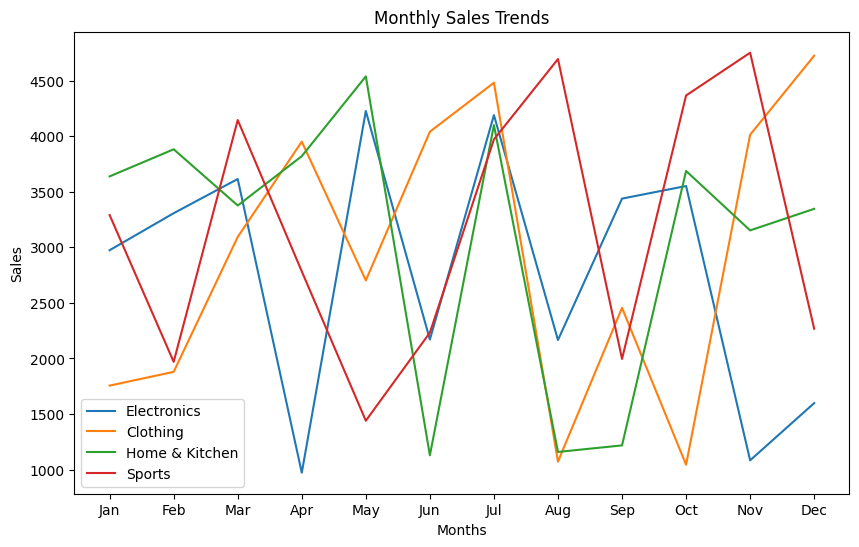

In [6]:
plt.figure(figsize=(10,6))

for col in columns:
    plt.plot(df.index, df[col], label=col)

plt.title("Monthly Sales Trends")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.legend()
plt.show()

Box Plot

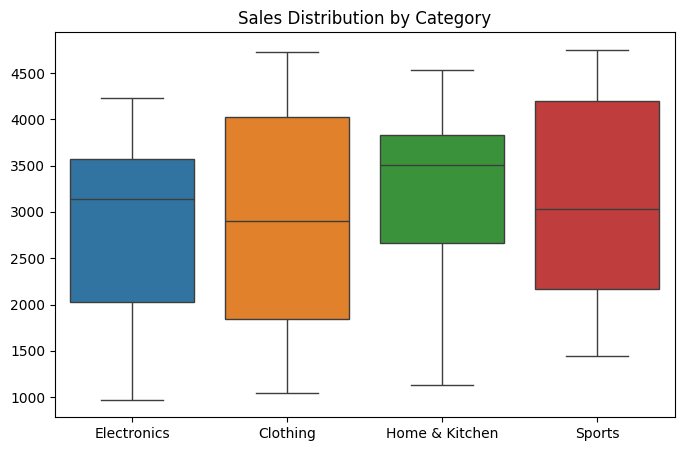

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[columns])

plt.title("Sales Distribution by Category")
plt.show()

Q2: NumPy Operations

In [8]:
array = np.array([[1, -2, 3], [-4, 5, -6]])

# Absolute value
print("Absolute:\n", np.abs(array))

# Percentiles
flat = array.flatten()
print("Percentiles:", np.percentile(flat, [25, 50, 75]))

# Mean, Median, Std
print("Mean:", np.mean(flat))
print("Median:", np.median(flat))
print("Std:", np.std(flat))

Absolute:
 [[1 2 3]
 [4 5 6]]
Percentiles: [-3.5 -0.5  2.5]
Mean: -0.5
Median: -0.5
Std: 3.8622100754188224


Q3: Rounding Functions

In [9]:
a = np.array([-1.8, -1.6, -0.5, 0.5, 1.6, 1.8, 3.0])

print("Floor:", np.floor(a))
print("Ceil:", np.ceil(a))
print("Trunc:", np.trunc(a))
print("Round:", np.round(a))

Floor: [-2. -2. -1.  0.  1.  1.  3.]
Ceil: [-1. -1. -0.  1.  2.  2.  3.]
Trunc: [-1. -1. -0.  0.  1.  1.  3.]
Round: [-2. -2. -0.  0.  2.  2.  3.]


Q4: Swap using temporary variable

In [10]:
lst = [10, 20, 30]

# swap first two
temp = lst[0]
lst[0] = lst[1]
lst[1] = temp

print("Swapped List:", lst)

Swapped List: [20, 10, 30]


Q5: Swap elements in set

In [11]:
s = {1, 2, 3}

# convert to list
lst = list(s)

# swap first two
lst[0], lst[1] = lst[1], lst[0]

# convert back
s = set(lst)

print("Swapped Set:", s)

Swapped Set: {1, 2, 3}
